# AI Powered E-Commerce Customer Intelligence System

**Final Data Science Hackathon — complete beginner-friendly solution**

This notebook follows the supplied student brief: SQLite inspection and cleaning, five SQL business queries, EDA, churn models, a small neural network, NLP sentiment analysis, and saved models for Streamlit.

The main rule for churn is important: features use orders **up to 31 May 2026**, while the target uses purchases from **1 June to 31 August 2026**. 

In [1]:
import os
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report

pd.set_option("display.max_columns", 50)

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DB_PATH = os.path.join(ROOT, "data", "ecommerce_hackathon.db")
MODEL_DIR = os.path.join(ROOT, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

conn = sqlite3.connect(DB_PATH)
print("Database connected:", DB_PATH)

Database connected: C:\Users\Admin\Downloads\ecommerce_hackathon_project\mnt\data\ecommerce_hackathon_project\data\ecommerce_hackathon.db


## Task A — Database inspection and cleaning

In [2]:
# Load each table directly from SQLite. We do not convert the whole database to CSV.
customers = pd.read_sql_query("SELECT * FROM customers", conn)
products = pd.read_sql_query("SELECT * FROM products", conn)
orders = pd.read_sql_query("SELECT * FROM orders", conn)
reviews = pd.read_sql_query("SELECT * FROM reviews", conn)

for name, df in {"customers":customers, "products":products, "orders":orders, "reviews":reviews}.items():
    print(name, "shape:", df.shape)
    print("Columns:", list(df.columns))
    print("Duplicate rows:", df.duplicated().sum())
    print()

customers shape: (8000, 9)
Columns: ['customer_id', 'customer_name', 'age', 'gender', 'city', 'signup_date', 'membership_type', 'email', 'phone']
Duplicate rows: 0

products shape: (1000, 6)
Columns: ['product_id', 'product_name', 'category', 'brand', 'unit_price', 'stock_quantity']
Duplicate rows: 0

orders shape: (65000, 10)
Columns: ['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'returned']
Duplicate rows: 0

reviews shape: (26000, 6)
Columns: ['review_id', 'customer_id', 'product_id', 'review_date', 'rating', 'review_text']
Duplicate rows: 0



In [3]:
# Data quality summary
for name, df in {"customers":customers, "products":products, "orders":orders, "reviews":reviews}.items():
    print("\n---", name, "---")
    print(df.isna().sum())

print("\nImportant checks:")
print("Orders with invalid quantity:", (orders["quantity"] <= 0).sum())
print("Orders with invalid unit price:", (orders["unit_price"] <= 0).sum())
print("Orders with missing payment:", orders["payment_method"].isna().sum())
print("Orders with missing delivery days:", orders["delivery_days"].isna().sum())
print("Reviews with invalid rating:", (~reviews["rating"].between(1,5)).sum())



--- customers ---
customer_id          0
customer_name        0
age                100
gender               0
city                 0
signup_date          0
membership_type      0
email                0
phone                0
dtype: int64

--- products ---
product_id         0
product_name       0
category           0
brand             20
unit_price         0
stock_quantity     0
dtype: int64

--- orders ---
order_id           0
customer_id        0
product_id         0
order_date         0
quantity           0
unit_price         0
discount           0
payment_method    55
delivery_days     40
returned           0
dtype: int64

--- reviews ---
review_id       0
customer_id     0
product_id      0
review_date     0
rating          0
review_text    48
dtype: int64

Important checks:
Orders with invalid quantity: 45
Orders with invalid unit price: 35
Orders with missing payment: 55
Orders with missing delivery days: 40
Reviews with invalid rating: 25


In [4]:
# Simple cleaning decisions:
# 1. Convert dates; invalid text such as 'unknown' becomes missing.
# 2. Fill customer age with the median because only a small number are missing.
# 3. Fill missing product brands with 'Unknown'.
# 4. Standardize category spelling/spacing.
# 5. For orders, remove rows with invalid quantity or price because revenue would be meaningless.
# 6. Fill missing payment method/delivery days with simple values.
# 7. For reviews, remove missing text and invalid ratings because they cannot make a valid sentiment label.

customers_clean = customers.copy()
products_clean = products.copy()
orders_clean = orders.copy()
reviews_clean = reviews.copy()

customers_clean["signup_date"] = pd.to_datetime(customers_clean["signup_date"], errors="coerce")
customers_clean["age"] = customers_clean["age"].fillna(customers_clean["age"].median())

products_clean["brand"] = products_clean["brand"].fillna("Unknown")
products_clean["category"] = products_clean["category"].astype(str).str.strip().str.title()

orders_clean["order_date"] = pd.to_datetime(orders_clean["order_date"], errors="coerce")
orders_clean["payment_method"] = orders_clean["payment_method"].fillna("Unknown")
orders_clean["delivery_days"] = orders_clean["delivery_days"].fillna(orders_clean["delivery_days"].median())
orders_clean = orders_clean[orders_clean["order_date"].notna()].copy()
orders_clean = orders_clean[(orders_clean["quantity"] > 0) & (orders_clean["unit_price"] > 0)].copy()

reviews_clean["review_date"] = pd.to_datetime(reviews_clean["review_date"], errors="coerce")
reviews_clean["review_text"] = reviews_clean["review_text"].fillna("").astype(str).str.strip()
reviews_clean = reviews_clean[reviews_clean["review_date"].notna()].copy()
reviews_clean = reviews_clean[reviews_clean["rating"].between(1,5)].copy()
reviews_clean = reviews_clean[reviews_clean["review_text"] != ""].copy()

# Re-check
print("Cleaned shapes:")
for name, df in {"customers":customers_clean, "products":products_clean, "orders":orders_clean, "reviews":reviews_clean}.items():
    print(name, df.shape)


Cleaned shapes:
customers (8000, 9)
products (1000, 6)
orders (64890, 10)
reviews (25869, 6)


## Task B — SQL business analysis

The five required queries are also saved in `sql_queries.sql`.

In [5]:
# Query 1: total net revenue
q1 = pd.read_sql_query("""
SELECT ROUND(SUM(unit_price * quantity * (1 - discount)), 2) AS total_net_revenue
FROM orders
WHERE returned = 0 AND unit_price > 0 AND quantity > 0;
""", conn)
q1

,total_net_revenue
0,8.654913e+08


In [6]:
# Query 2: top 10 customers
q2 = pd.read_sql_query("""
SELECT c.customer_name, c.city,
       COUNT(DISTINCT o.order_id) AS number_of_orders,
       ROUND(SUM(o.unit_price * o.quantity * (1 - o.discount)), 2) AS total_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.returned = 0 AND o.unit_price > 0 AND o.quantity > 0
GROUP BY c.customer_id, c.customer_name, c.city
ORDER BY total_spending DESC
LIMIT 10;
""", conn)
q2

,customer_name,city,number_of_orders,total_spending
0,Shahzaib Abbasi,Lahore,37,1537800.62
1,Zoya Awan,Lahore,50,1515401.07
2,Ahmed Qureshi,Lahore,27,1452407.09
3,Kiran Farooq,Karachi,57,1353157.41
4,Laiba Khan,Karachi,40,1340945.41
5,Adeel Khan,Karachi,38,1333846.74
6,Fahad Khan,Islamabad,51,1252693.65
7,Bilal Awan,Karachi,45,1248563.98
8,Imran Qureshi,Karachi,44,1247069.53
9,Danish Awan,Faisalabad,43,1240877.18


In [7]:
# Query 3: category analysis
q3 = pd.read_sql_query("""
SELECT p.category,
       ROUND(SUM(o.unit_price * o.quantity * (1 - o.discount)), 2) AS revenue,
       COUNT(DISTINCT o.order_id) AS order_count,
       SUM(o.quantity) AS quantity_sold
FROM orders o
JOIN products p ON o.product_id = p.product_id
WHERE o.returned = 0 AND o.unit_price > 0 AND o.quantity > 0
GROUP BY p.category
ORDER BY revenue DESC;
""", conn)
q3

,category,revenue,order_count,quantity_sold
0,Electronics,5.897190e+08,10160,14229
1,Home & Kitchen,6.529115e+07,7032,9931
2,Fashion,5.464882e+07,10680,14967
3,Sports & Fitness,5.147900e+07,6657,9357
4,Beauty,4.351566e+07,10872,15105
5,Baby & Kids,2.701127e+07,3493,4979
6,electronics,1.134563e+07,173,244
7,Groceries,7.829888e+06,5915,8264
8,Books & Stationery,7.312427e+06,4821,6675
9,ELECTRONICS,3.038298e+06,249,346


In [8]:
# Query 4: monthly net revenue
q4 = pd.read_sql_query("""
SELECT strftime('%Y-%m', order_date) AS month,
       ROUND(SUM(unit_price * quantity * (1 - discount)), 2) AS net_revenue
FROM orders
WHERE returned = 0 AND unit_price > 0 AND quantity > 0
  AND date(order_date) IS NOT NULL
GROUP BY month
ORDER BY month;
""", conn)
q4

,month,net_revenue
0,2022-03,8425.49
1,2022-04,80746.37
2,2022-05,119461.53
3,2022-06,203912.12
4,2022-07,89778.47
5,2022-08,698996.03
6,2022-09,293353.07
7,2022-10,361749.29
8,2022-11,895729.89
9,2022-12,558315.69


In [9]:
# Query 5: top 5 products
q5 = pd.read_sql_query("""
SELECT p.product_name, p.category,
       ROUND(SUM(o.unit_price * o.quantity * (1 - o.discount)), 2) AS net_revenue
FROM orders o
JOIN products p ON o.product_id = p.product_id
WHERE o.returned = 0 AND o.unit_price > 0 AND o.quantity > 0
GROUP BY p.product_id, p.product_name, p.category
ORDER BY net_revenue DESC
LIMIT 5;
""", conn)
q5

,product_name,category,net_revenue
0,Samsung Headphones Classic,Electronics,1.056982e+08
1,Anker Headphones Classic,Electronics,6.601398e+07
2,Dawlance LED TV Premium,Electronics,1.903070e+07
3,Infinix LED TV 2026,Electronics,1.565400e+07
4,Dawlance Router Eco,Electronics,1.417660e+07


## Task C — Exploratory Data Analysis

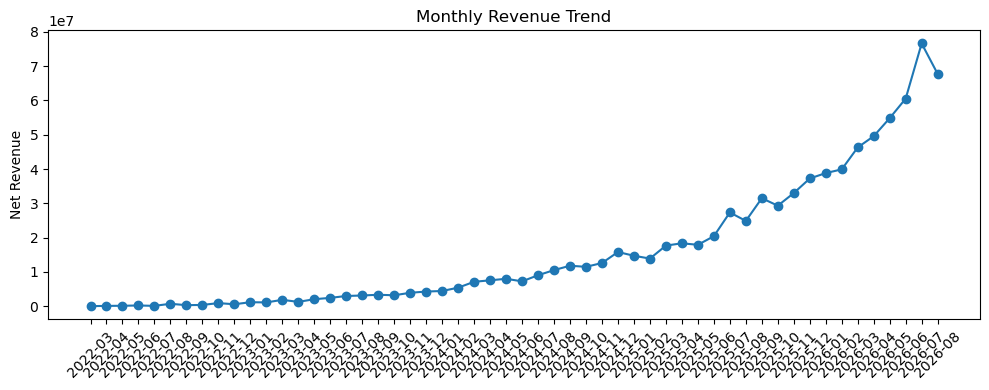

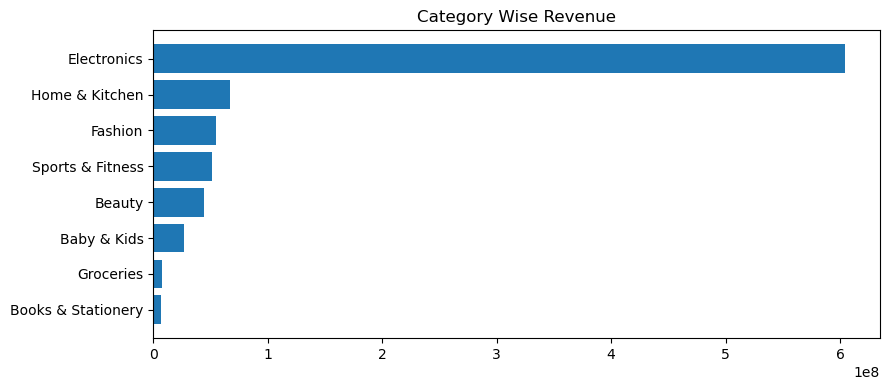

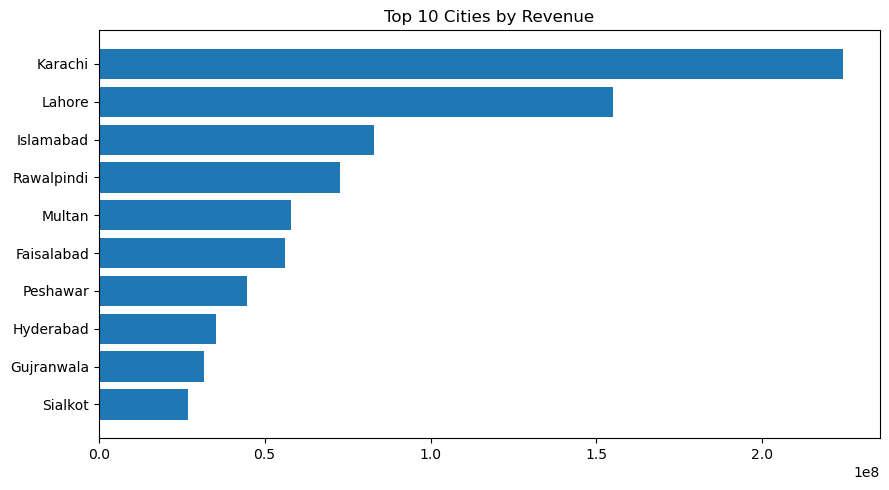

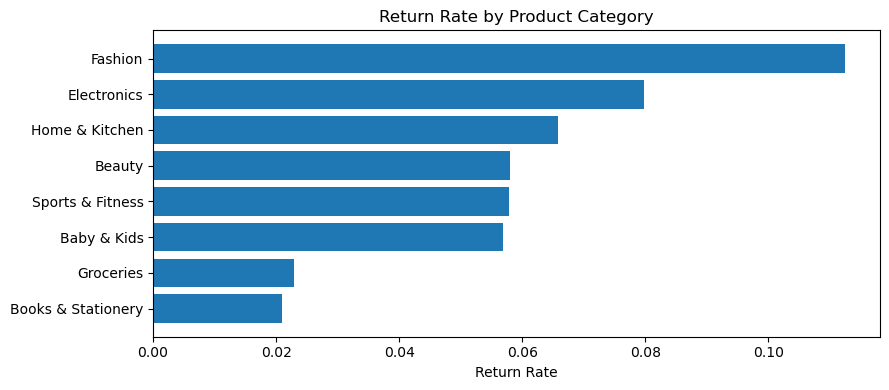

Business insights:
1. The monthly chart shows when revenue rises or falls, which can help the business plan inventory and promotions.
2. Category revenue shows which product groups contribute most to sales, helping management focus commercial resources.
3. Category return rates show where customers return products more often; those categories may need product-quality, description, or delivery review.


In [10]:
# Create a revenue column for EDA.
eda = orders_clean.merge(products_clean[["product_id","category"]], on="product_id", how="left")
eda["net_revenue"] = eda["unit_price"] * eda["quantity"] * (1 - eda["discount"])
eda = eda[eda["returned"] == 0].copy()

monthly = eda.assign(month=eda["order_date"].dt.to_period("M").astype(str)).groupby("month", as_index=False)["net_revenue"].sum()
category_rev = eda.groupby("category", as_index=False)["net_revenue"].sum().sort_values("net_revenue", ascending=False)
city_rev = eda.merge(customers_clean[["customer_id","city"]], on="customer_id", how="left").groupby("city", as_index=False)["net_revenue"].sum().sort_values("net_revenue", ascending=False).head(10)

# Return rate by category
all_cat = orders_clean.merge(products_clean[["product_id","category"]], on="product_id", how="left")
return_rate = all_cat.groupby("category").agg(
    total_orders=("order_id","count"),
    returned_orders=("returned","sum")
).reset_index()
return_rate["return_rate"] = return_rate["returned_orders"] / return_rate["total_orders"]
return_rate = return_rate.sort_values("return_rate", ascending=False)

plt.figure(figsize=(10,4))
plt.plot(monthly["month"], monthly["net_revenue"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.ylabel("Net Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.barh(category_rev["category"], category_rev["net_revenue"])
plt.gca().invert_yaxis()
plt.title("Category Wise Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
plt.barh(city_rev["city"], city_rev["net_revenue"])
plt.gca().invert_yaxis()
plt.title("Top 10 Cities by Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.barh(return_rate["category"], return_rate["return_rate"])
plt.gca().invert_yaxis()
plt.title("Return Rate by Product Category")
plt.xlabel("Return Rate")
plt.tight_layout()
plt.show()

print("Business insights:")
print("1. The monthly chart shows when revenue rises or falls, which can help the business plan inventory and promotions.")
print("2. Category revenue shows which product groups contribute most to sales, helping management focus commercial resources.")
print("3. Category return rates show where customers return products more often; those categories may need product-quality, description, or delivery review.")

## Task D — Customer churn prediction

In [11]:
# Churn setup from the brief
feature_end = pd.Timestamp("2026-05-31")
target_start = pd.Timestamp("2026-06-01")
target_end = pd.Timestamp("2026-08-31")

pre_orders = orders_clean[orders_clean["order_date"] <= feature_end].copy()
target_orders = orders_clean[(orders_clean["order_date"] >= target_start) & (orders_clean["order_date"] <= target_end)].copy()

# Only customers with at least one purchase before the cutoff are eligible.
eligible_ids = pre_orders["customer_id"].unique()

features = pre_orders.groupby("customer_id").agg(
    total_orders=("order_id","nunique"),
    total_spending=("unit_price", lambda x: 0),  # replaced below
).reset_index()

# Spending needs quantity and discount, so calculate it first.
pre_orders["order_value"] = pre_orders["unit_price"] * pre_orders["quantity"] * (1 - pre_orders["discount"])

features = pre_orders.groupby("customer_id").agg(
    total_orders=("order_id","nunique"),
    total_spending=("order_value","sum"),
    avg_order_value=("order_value","mean"),
    last_order_date=("order_date","max"),
    return_rate=("returned","mean"),
    avg_delivery_days=("delivery_days","mean")
).reset_index()

features["days_since_last_order"] = (feature_end - features["last_order_date"]).dt.days
features = features.drop(columns=["last_order_date"])

features = features.merge(customers_clean[["customer_id","age","membership_type"]], on="customer_id", how="left")

# Target: no purchase in the target window = churn 1
active_ids = set(target_orders["customer_id"])
features["churn"] = features["customer_id"].apply(lambda x: 0 if x in active_ids else 1)

features = features.dropna()
print("Churn dataset:", features.shape)
print(features["churn"].value_counts(normalize=True))
features.head()

Churn dataset: (6535, 10)
churn
0    0.509411
1    0.490589
Name: proportion, dtype: float64


,customer_id,total_orders,total_spending,avg_order_value,return_rate,avg_delivery_days,days_since_last_order,age,membership_type,churn
0,2,3,6229.49896,2076.499653,0.0,4.666667,3,33.0,Silver,0
1,3,6,24102.46210,4017.077017,0.0,3.166667,107,25.0,Standard,1
2,4,5,14400.81290,2880.162580,0.0,3.000000,13,26.0,Standard,1
3,5,8,76312.80669,9539.100836,0.0,3.500000,19,27.0,Standard,0
4,6,3,50020.16297,16673.387657,0.0,3.000000,440,24.0,Standard,1


In [12]:
X = features.drop(columns=["customer_id","churn"])
y = features["churn"]

numeric_features = [
    "total_orders","total_spending","avg_order_value",
    "days_since_last_order","return_rate","avg_delivery_days","age"
]
categorical_features = ["membership_type"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

logistic = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

forest = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=150, random_state=42, class_weight="balanced"))
])

logistic.fit(X_train, y_train)
forest.fit(X_train, y_train)

def evaluate_model(name, model):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test,pred),
        "Precision": precision_score(y_test,pred,zero_division=0),
        "Recall": recall_score(y_test,pred,zero_division=0),
        "F1": f1_score(y_test,pred,zero_division=0),
        "ROC-AUC": roc_auc_score(y_test,prob)
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression", logistic),
    evaluate_model("Random Forest", forest)
])
results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.715,0.667,0.839,0.743,0.787
1,Random Forest,0.688,0.660,0.749,0.702,0.759


In [13]:
# Confusion matrices for both models
for name, model in [("Logistic Regression", logistic), ("Random Forest", forest)]:
    pred = model.predict(X_test)
    print(name)
    print(confusion_matrix(y_test, pred))
    print()

# Save the random forest as the app's churn model.
joblib.dump(forest, os.path.join(MODEL_DIR, "churn_model.joblib"))
joblib.dump({
    "numeric_features": numeric_features,
    "categorical_features": categorical_features
}, os.path.join(MODEL_DIR, "churn_features.joblib"))
print("Saved churn model.")

Logistic Regression
[[397 269]
 [103 538]]

Random Forest
[[419 247]
 [161 480]]

Saved churn model.


## Task E — Small feed-forward neural network

In [14]:
# MLPClassifier is a simple feed-forward neural network.
# Hidden layers 32 -> 16 match the simple architecture suggested in the brief.
neural_network = Pipeline([
    ("prep", preprocessor),
    ("model", MLPClassifier(hidden_layer_sizes=(32,16), activation="relu",
                            solver="adam", max_iter=300, random_state=42,
                            early_stopping=True))
])

neural_network.fit(X_train, y_train)
nn_results = evaluate_model("Neural Network", neural_network)
pd.DataFrame([nn_results]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Neural Network,0.714,0.677,0.796,0.732,0.785


**Deep Learning conclusion:** A small neural network can be compared on the same test set, but the extra complexity should only be kept if it provides a meaningful improvement in the required metrics. For a compact tabular hackathon project, a simpler model is easier to explain and deploy when performance is similar.

## Task F — NLP sentiment analysis

In [15]:
sentiment = reviews_clean.copy()
sentiment["sentiment"] = sentiment["rating"].apply(
    lambda x: "Negative" if x <= 2 else ("Neutral" if x == 3 else "Positive")
)

print(sentiment["sentiment"].value_counts())
sentiment[["rating","sentiment","review_text"]].head()

sentiment
Positive    18410
Neutral      5454
Negative     2005
Name: count, dtype: int64


,rating,sentiment,review_text
0,4,Positive,"I would buy this again, item feels durable. Re..."
1,5,Positive,"Very satisfied, seller description was accurat..."
2,4,Positive,"Very satisfied, quality feels premium. Good va..."
3,4,Positive,"Product arrived in great condition, quality fe..."
4,4,Positive,"Good experience overall, packing was neat. Wil..."


In [16]:
X_text = sentiment["review_text"]
y_text = sentiment["sentiment"]

Xtr, Xte, ytr, yte = train_test_split(
    X_text, y_text, test_size=0.20, random_state=42, stratify=y_text
)

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

Xtr_tfidf = tfidf.fit_transform(Xtr)
Xte_tfidf = tfidf.transform(Xte)

sentiment_model = LogisticRegression(max_iter=1000)
sentiment_model.fit(Xtr_tfidf, ytr)

text_pred = sentiment_model.predict(Xte_tfidf)

print("Accuracy:", round(accuracy_score(yte,text_pred),3))
print("Precision:", round(precision_score(yte,text_pred,average="weighted",zero_division=0),3))
print("Recall:", round(recall_score(yte,text_pred,average="weighted",zero_division=0),3))
print("F1:", round(f1_score(yte,text_pred,average="weighted",zero_division=0),3))
print("\nClassification report:")
print(classification_report(yte,text_pred,zero_division=0))

# Save vectorizer + classifier together so the Streamlit app uses the saved NLP model.
sentiment_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", max_features=5000)),
    ("model", LogisticRegression(max_iter=1000))
])
sentiment_pipeline.fit(Xtr, ytr)
joblib.dump(sentiment_pipeline, os.path.join(MODEL_DIR, "sentiment_model.joblib"))
print("Saved sentiment model.")

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Classification report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       401
     Neutral       1.00      1.00      1.00      1091
    Positive       1.00      1.00      1.00      3682

    accuracy                           1.00      5174
   macro avg       1.00      1.00      1.00      5174
weighted avg       1.00      1.00      1.00      5174

Saved sentiment model.


Saved sentiment model.


**NLP limitation:** The sentiment labels are created from star ratings, so a rating does not always perfectly represent the actual language in a review. This can introduce label noise.

## Task G — Streamlit preparation

The saved models are loaded by `app/streamlit_app.py`. The app has Dashboard, Churn Prediction, and Sentiment Analysis sections. At least three dashboard outputs come directly from SQL queries in the app.

In [17]:
# Check that all required model files exist.
for filename in ["churn_model.joblib","churn_features.joblib","sentiment_model.joblib"]:
    path = os.path.join(MODEL_DIR, filename)
    print(filename, "exists:", os.path.exists(path), "size:", os.path.getsize(path) if os.path.exists(path) else 0)

conn.close()
print("Notebook work completed.")

churn_model.joblib exists: True size: 28980978
churn_features.joblib exists: True size: 197
sentiment_model.joblib exists: True size: 10132
Notebook work completed.
